# Generative LMC arm — valence/arousal stimulus pipeline (Lyria 3)

This notebook builds the **256 song–lyric pairs** for the human-validation survey of
Lyric-Music Congruence (LMC), end to end. (§3b lets you dial this down to a small smoke
test before committing to the full batch.)

**Design (2×2 valence/arousal circumplex):**

| | | |
|---|---|---|
| **4 extreme VA corners** (music targets) | × **16 two-line lyrics** (4 authored per corner) | × **4 repetitions** = **256 songs** |

Every crossing of *lyric corner* and *music corner* is covered, so congruence ranges
from perfectly matched (the 4×4 diagonal) to opposite-corner mismatched.

- **Corners:** `hvha` (joyful/euphoric), `hvla` (calm/content), `lvha` (angry/afraid), `lvla` (sad/weary).
- **Generation:** Google **Lyria 3 Clip** via the Gemini API (`GEMINI_API_KEY`).
  Lyria takes the lyrics as `[Chorus]` tags + the musical style as prose — it has **no
  embedding input, no seed, and does not reproduce**, so each corner is hit by prompt
  engineering and *validated post-hoc* against a MuLan target embedding.
- **Validation:** Whisper **WER** (lyrics sung faithfully?), **MuLan** audio-vs-corner
  anchor cosine (music in the target corner?), and **librosa acoustic VA** (independent
  valence/arousal). Realised **LMC** = cos(audio, own-lyric text) in MuLan — the same
  definition as the observational arm.

Run top to bottom in **dry-run** first (mock audio, no API calls) to check the plumbing,
then flip to real Lyria. Everything is **resumable** — a stopped batch skips finished clips.

Kernel: **Python (lmc)**.

## 0 · Setup

In [1]:
import os, sys, logging
from pathlib import Path

# Load API keys from notebooks/.env into os.environ (GEMINI_API_KEY for Lyria).
from dotenv import load_dotenv
load_dotenv(Path.cwd() / ".env")

# Make the src/ packages importable (lmc, lmcgen).
REPO = Path.cwd().parent
sys.path.insert(0, str(REPO / "src"))

logging.basicConfig(level=logging.INFO, format="%(message)s")

from lmcgen import config, quadrants, lyrics, generate, validate, analysis
config.ensure_dirs()
print(config.summary())

Repo root      : /Users/budge.13/Desktop/Music Analysis
Generation dir : /Users/budge.13/Desktop/Music Analysis/data/generation
Results dir    : /Users/budge.13/Desktop/Music Analysis/results/generation
Figures dir    : /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation
VA corners     : hvha, hvla, lvha, lvla
Design         : 16 lyrics (4/4 per corner) x 4 music corners x 4 reps = 256 songs (~30s each)
Backend        : Lyria — lyria-3-clip-preview (candidates/slot=1)
Lyric screening: on (Whisper small)
CLAP validator : off
GEMINI_API_KEY : set
DRY_RUN        : True   (MOCK audio — plumbing only)


## 1 · The design: four VA corners

In [2]:
import pandas as pd
pd.DataFrame([{ "corner": q.code, "label": q.label, "valence": q.valence,
                "arousal": q.arousal, "bpm": q.bpm, "key": q.keyscale,
                "style": q.style_words[:60] + "…" } for q in quadrants.ALL]).set_index("corner")

,label,valence,arousal,bpm,key,style
corner,,,,,,
hvha,"high valence / high arousal (joyful, euphoric)",0.92,0.88,150,E major,"bright major key, fast upbeat tempo around 150..."
hvla,"high valence / low arousal (calm, content, ser...",0.90,0.12,68,C major,"warm major key, slow gentle tempo around 68 BP..."
lvha,"low valence / high arousal (angry, afraid, tense)",0.10,0.90,160,D minor,"dark minor key, fast aggressive tempo around 1..."
lvla,"low valence / low arousal (sad, weary, hopeless)",0.10,0.12,60,A minor,"slow minor key, sparse tempo around 60 BPM, sa..."


## 2 · The sixteen lyric stimuli + placement checks

Each couplet is checked two model-independent ways: a **lexical** count against each
corner's affect vocabulary, and a **VA-lexicon** score (its nearest corner). Both should
point to the target corner. (A third check — MuLan text-anchor cosine — is in §3.)

In [3]:
for c in lyrics.ALL:
    print(f"{c.lyric_id:8s} | {c.lines[0]} / {c.lines[1]}")
print()
print("lexical placement correct:", lyrics.lexical_alignment()['correct'].mean())
print("VA-lexicon placement correct:", lyrics.va_alignment()['correct'].mean(),
      "(the bundled VAD lexicon is a coarse stopgap; lexical + MuLan are the strong checks)")
analysis.lyric_placement()

hvha_1   | Hands in the air, we're burning gold tonight / Alive, alive, the whole world's alight
hvha_2   | Turn it up loud, we're dancing through the fire / Higher and higher, we never tire
hvha_3   | Feel the rush, the city's ours to run / Chasing the light, we're second to none
hvha_4   | Electric hearts and a sky full of flame / Shout it out loud, we're never the same
hvla_1   | Soft morning light, your hand holds mine / Slow and warm, everything's fine
hvla_2   | Rest your head, the world is still / Quiet and safe on this gentle hill
hvla_3   | A calm breeze hums, the evening's kind / Peace in my chest, ease in my mind
hvla_4   | Home at last and the fire burns low / Close and warm, nowhere to go
lvha_1   | Burn it down, I'll fight you to the end / Tear down every wall you defend
lvha_2   | Run, don't stop, the dark is closing in / Something with teeth knows where I've been
lvha_3   | Blood in my mouth, I'm ready for the war / Break down the walls, I want more
lvha_4   | Fists and

,quadrant,lex_pred,lex_correct,lyric_v,lyric_a,va_pred,va_correct
lyric_id,,,,,,,
hvha_1,hvha,hvha,True,0.687,0.652,hvha,True
hvha_2,hvha,hvha,True,0.420,0.780,lvha,False
hvha_3,hvha,hvha,True,0.550,0.625,hvha,True
hvha_4,hvha,hvha,True,0.580,0.400,hvla,False
hvla_1,hvla,hvla,True,0.673,0.450,hvla,True
hvla_2,hvla,hvla,True,0.515,0.360,hvla,True
hvla_3,hvla,hvla,True,0.765,0.265,hvla,True
hvla_4,hvla,hvla,True,0.497,0.560,lvha,False
lvha_1,lvha,lvha,True,0.355,0.590,lvha,True


## 3 · (Optional) MuLan text-anchor placement of the lyrics

Embeds each couplet's **text** and scores it against the four VA-corner anchors — a third,
embedding-based placement check on the *lyric* side (independent of the music generation).
Loads MuLan, so skip it if you only want to generate.

In [ ]:
from lmcgen import mulan
scorer = mulan.Scorer('mulan')
anchors = scorer.build_anchors()
rows = []
for c in lyrics.ALL:
    s = scorer.score_against_anchors(mulan._unit(scorer.embed_text(c.plain)), anchors)
    rows.append({'lyric_id': c.lyric_id, 'target': c.quadrant,
                 'pred': mulan.argmax(s), **{f'cos_{k}': round(v,3) for k,v in s.items()}})
text_place = pd.DataFrame(rows).set_index('lyric_id')
text_place['correct'] = text_place['pred'] == text_place['target']
print('MuLan text-anchor placement correct:', text_place['correct'].mean())
del scorer, anchors
text_place

## 3b · Smoke-test controls

Before spending API quota (or waiting through a big local batch), you can shrink the
design with two toggles, read live by `generate.build_specs()`:

- `config.ACTIVE_LYRICS_PER_QUADRANT` — how many of the 4 authored lyrics per corner to
  include (1–4). Default 4 (all of them).
- `config.REPS_PER_CELL` — how many generations per (lyric × music-quadrant) cell.
  Default 4.

Total songs = `(4 corners × ACTIVE_LYRICS_PER_QUADRANT lyrics) × 4 music corners ×
REPS_PER_CELL reps`. Set both to `1` for a **16-song smoke test** — one song per cell of
the full 4×4 congruence matrix, the cheapest way to sanity-check prompts/voice/quality
before committing to the full 256. Set them back to `4` to return to the full design —
`generate_all()` / `validate_all()` are resumable, so growing the active set later just
generates the songs that weren't covered by the smaller run.

In [4]:
# Set these before generating. Defaults (4, 4) = the full 256-song study design.
config.ACTIVE_LYRICS_PER_QUADRANT = 1   # 1-4: how many of the 4 lyrics/corner to use
config.REPS_PER_CELL = 1                # generations per (lyric x music-quadrant) cell

print(config.summary())
print('planned songs:', len(generate.build_specs()))

Repo root      : /Users/budge.13/Desktop/Music Analysis
Generation dir : /Users/budge.13/Desktop/Music Analysis/data/generation
Results dir    : /Users/budge.13/Desktop/Music Analysis/results/generation
Figures dir    : /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation
VA corners     : hvha, hvla, lvha, lvla
Design         : 4 lyrics (1/4 per corner) x 4 music corners x 1 reps = 16 songs (~30s each)   [SMOKE TEST]
Backend        : Lyria — lyria-3-clip-preview (candidates/slot=1)
Lyric screening: on (Whisper small)
CLAP validator : off
GEMINI_API_KEY : set
DRY_RUN        : True   (MOCK audio — plumbing only)
planned songs: 16


## 4 · Phase 1 — generate the songs

**Dry-run first** (`LMCGEN_DRY_RUN=1`, the default): writes cheap VA-dependent *mock*
clips so the whole pipeline runs with no API calls. Resumable — re-running skips clips
already on disk. Uses whatever `ACTIVE_LYRICS_PER_QUADRANT` / `REPS_PER_CELL` are set to
in §3b (256 songs at the full-study defaults, fewer for a smoke test).

In [ ]:
print('DRY_RUN =', config.DRY_RUN, '| coverage before:', generate.coverage())
generate.generate_all()          # dry-run mock unless LMCGEN_DRY_RUN=0
print('coverage after:', generate.coverage())

### Switching to **real** Lyria generation

1. Confirm `GEMINI_API_KEY` is set (see §0 summary) and `pip install google-genai`.
2. **Recommended: run a small smoke test first.** In §3b, set
   `config.ACTIVE_LYRICS_PER_QUADRANT = 1` and `config.REPS_PER_CELL = 1` (16 songs,
   one per cell of the 4×4 matrix) to check voice/quality/cost before the full batch.
3. Set the env var and restart the kernel, **or** set it before importing:
   ```python
   os.environ['LMCGEN_DRY_RUN'] = '0'
   ```
4. **Clear the mock clips once** so they aren't reused as if real:
   ```python
   generate.clean_generated()      # deletes audio + embeddings + anchors + results
   ```
5. Re-run the generate cell. Real generation is **one preview-API call per song**
   (256 at the full-study defaults, fewer for a smoke test) — it costs quota and takes
   a while; it is resumable, so you can stop and resume. Watch for rate-limit retries
   in the log. When you're satisfied with a smoke test, bump `ACTIVE_LYRICS_PER_QUADRANT`
   / `REPS_PER_CELL` back to `4` and re-run — already-generated clips are skipped.

> To keep the best-of-N take per rep instead of a single call, set `LMCGEN_CANDIDATES=3`
> (needs `faster-whisper`); the default (1) generates each rep once and lets §5 validate
> everything so you can pick winners afterwards.

In [5]:
# --- REAL generation (uncomment to run) ---
os.environ['LMCGEN_DRY_RUN'] = '0'
config.DRY_RUN = False          # NOTE: don't importlib.reload(config) here — that would
                                 # reset ACTIVE_LYRICS_PER_QUADRANT / REPS_PER_CELL (set in
                                 # §3b) back to their defaults. Setting DRY_RUN directly
                                 # keeps those toggles intact.
generate.clean_generated()
generate.generate_all(dry_run=False)
print(generate.coverage())

removed /Users/budge.13/Desktop/Music Analysis/data/generation/audio
removed /Users/budge.13/Desktop/Music Analysis/data/generation/embeddings
removed /Users/budge.13/Desktop/Music Analysis/data/generation/anchors
removed /Users/budge.13/Desktop/Music Analysis/results/generation
Generating 16 songs (dry_run=False, candidates/slot=1)…
[1/16] hvha_1 x hvha rep0
HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/interactions "HTTP/1.1 200 OK"
  generated (lyria): hvha_1__hvha__rep0.wav
     elapsed 0m, ~3m remaining
[2/16] hvha_1 x hvla rep0
HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/interactions "HTTP/1.1 200 OK"
  generated (lyria): hvha_1__hvla__rep0.wav
     elapsed 0m, ~3m remaining
[3/16] hvha_1 x lvha rep0
HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/interactions "HTTP/1.1 200 OK"
  generated (lyria): hvha_1__lvha__rep0.wav
     elapsed 1m, ~2m remaining
[4/16] hvha_1 x lvla rep0
HTTP Request: POST https://generativel

{'total': 16, 'generated': 16, 'remaining': 0}


## 5 · Phase 2 — validate every song → `songs.csv`

Runs one Whisper/librosa pass (lyric WER + acoustic VA) and one MuLan pass (audio-vs-
corner anchors + realised LMC) over every generated clip, writing
`results/generation/songs.csv`. Set `use_asr=False` to skip Whisper (e.g. in dry-run,
where lyrics aren't really sung).

In [6]:
songs = validate.validate_all(use_asr=not config.DRY_RUN)
print(songs.shape)
songs.head()

Measuring lyric WER + acoustic VA on all clips…
Loading Whisper (small, cpu/int8) for lyric screening…
HTTP Request: GET https://huggingface.co/api/models/Systran/faster-whisper-small/revision/main "HTTP/1.1 200 OK"
Processing audio with duration 00:30.772
Processing audio with duration 00:30.772
Processing audio with duration 00:30.772
Processing audio with duration 00:30.171
Processing audio with duration 00:30.772
Processing audio with duration 00:30.380
Processing audio with duration 00:30.772
Processing audio with duration 00:29.858
Processing audio with duration 00:30.772
Processing audio with duration 00:30.772
Processing audio with duration 00:30.772
Processing audio with duration 00:30.772
Processing audio with duration 00:30.772
Processing audio with duration 00:30.772
Processing audio with duration 00:30.772
Processing audio with duration 00:30.772
Loading MuQ-MuLan on mps…
HTTP Request: HEAD https://huggingface.co/OpenMuQ/MuQ-MuLan-large/resolve/main/config.json "HTTP/1.1 3

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
HTTP Request: HEAD https://huggingface.co/OpenMuQ/MuQ-MuLan-large/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
HTTP Request: HEAD https://huggingface.co/OpenMuQ/MuQ-MuLan-large/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
Anchors[mulan]: embedding 4 VA-corner prompt sets…
HTTP Request: HEAD https://huggingface.co/xlm-roberta-base/resolve/main/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/xlm-roberta-base/resolve/main/tokenizer_config.json "HTTP/1.1 2

(16, 24)


,lyric_id,music_quadrant,rep,lyric_quadrant,congruent,path,design_music_v,design_music_a,lyric_v,lyric_a,...,audio_a,va_pred_quadrant,va_dist_to_target,mulan_target_anchor_cos,mulan_pred_quadrant,mulan_lmc_cross,mulan_anchor__hvha,mulan_anchor__hvla,mulan_anchor__lvha,mulan_anchor__lvla
0,hvha_1,hvha,0,hvha,True,/Users/budge.13/Desktop/Music Analysis/data/ge...,0.92,0.88,0.687,0.652,...,0.620130,hvha,0.400776,0.272968,hvha,0.334646,0.272968,0.017597,-0.032452,-0.007486
1,hvha_1,hvla,0,hvha,False,/Users/budge.13/Desktop/Music Analysis/data/ge...,0.90,0.12,0.687,0.652,...,0.323363,lvla,0.518298,0.470939,hvla,0.281123,-0.142896,0.470939,-0.231133,0.407411
2,hvha_1,lvha,0,hvha,False,/Users/budge.13/Desktop/Music Analysis/data/ge...,0.10,0.90,0.687,0.652,...,0.687203,hvha,0.564240,0.325499,lvha,0.355586,0.084861,0.019138,0.325499,0.046695
3,hvha_1,lvla,0,hvha,False,/Users/budge.13/Desktop/Music Analysis/data/ge...,0.10,0.12,0.687,0.652,...,0.416537,hvla,0.552253,0.379638,lvla,0.259248,-0.092614,0.259783,-0.127804,0.379638
4,hvla_1,hvha,0,hvla,False,/Users/budge.13/Desktop/Music Analysis/data/ge...,0.92,0.88,0.673,0.450,...,0.574147,hvha,0.371350,0.251679,hvha,0.146060,0.251679,-0.042116,-0.021699,-0.009685


## 6 · Analysis

**Manipulation check** — did the music land in its target corner? (MuLan argmax + the
independent acoustic-VA nearest-corner.) **Congruence matrix** — mean realised LMC across
the 4×4 lyric×music design (diagonal = congruent). Plus the VA scatter and confusion.

*(In dry-run these numbers are meaningless by construction — the mock audio only varies
systematically enough to exercise the plumbing.)*

=== manipulation accuracy (music lands in target corner) ===
mulan_anchor    0.9375
acoustic_va     0.3750
Name: accuracy_vs_target, dtype: float64

=== realised LMC: congruent vs incongruent ===
                                   mean       std  count
congruent                                               
False                          0.200244  0.097681   12.0
True                           0.347468  0.109654    4.0
gap (congruent − incongruent)  0.147224       NaN   16.0

=== lyric WER ===
{'median_wer': 0.0, 'pct_vocal_present': 0.75, 'median_wer_by_music': music_quadrant
hvha    0.53125
hvla    0.00000
lvha    0.50000
lvla    0.00000
Name: wer, dtype: float64}

=== congruence matrix (mean mulan_lmc_cross) ===


music_quadrant,hvha,hvla,lvha,lvla
lyric_quadrant,,,,
hvha,0.335,0.281,0.356,0.259
hvla,0.146,0.379,0.057,0.360
lvha,0.139,0.146,0.470,0.192
lvla,0.079,0.208,0.180,0.206


  wrote /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation/va_scatter.png
  wrote /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation/congruence_mulan_lmc_cross.png
  wrote /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation/confusion_mulan_pred_quadrant.png


figures → /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation


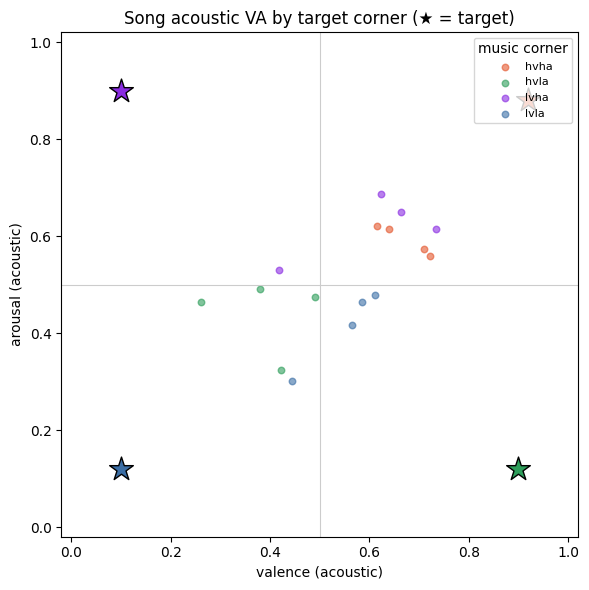

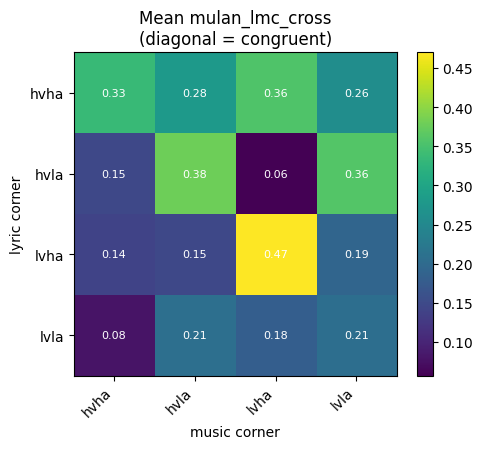

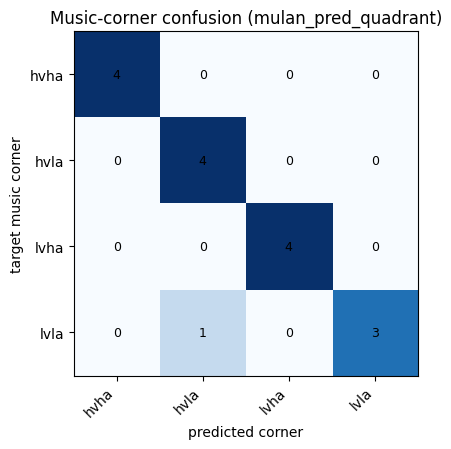

In [7]:
print('=== manipulation accuracy (music lands in target corner) ===')
print(analysis.manipulation_accuracy(songs))
print('\n=== realised LMC: congruent vs incongruent ===')
print(analysis.lmc_summary(songs))
print('\n=== lyric WER ===')
print(analysis.wer_summary(songs))
print('\n=== congruence matrix (mean mulan_lmc_cross) ===')
display(analysis.congruence_matrix(songs).round(3))
analysis.plot_va_scatter(songs)
analysis.plot_congruence_heatmap(songs)
analysis.plot_confusion(songs)
print('figures →', config.FIGURE_DIR)

## 7 · Winner selection + survey export

For each (lyric × music-quadrant) cell, rank its reps by how well they hit the target
(low acoustic-VA distance, high MuLan target-anchor cosine) **and** how intelligible they
are (low WER), and keep the best (`SURVEY['per_cell']`). The winners are copied to
`data/generation/survey/`, **loudness-normalised** to ~-14 LUFS (so loudness doesn't
confound arousal ratings), with a `manifest.csv` for the respondent study.

In [ ]:
winners = analysis.winner_selection(songs)
print('winners:', len(winners), '(one per lyric×music cell)')
manifest = analysis.export_survey(winners)
print('survey stimuli →', config.SURVEY_DIR)
manifest.head(8)

## Notes & recommendations for the survey

- **Loudness** is normalised on export; keep the 30 s clip length constant across items.
- **Pick winners** (§7) rather than random reps, so no dud stimulus (buried vocal / off-
  target music) reaches respondents; keep the other reps as a reserve pool.
- **Counterbalance** item order and add attention-check items. Collect, per item: perceived
  **valence**, **arousal**, **liking**, and a **lyric-comprehension** check — the last lets
  you screen items whose lyrics weren't audible independent of Whisper WER.
- **Congruence** for analysis is the 4×4 design (lyric corner vs music corner); the
  diagonal is congruent, the anti-diagonal maximally incongruent.
- **Licensing:** all Lyria audio carries a **SynthID** watermark and the model is in
  preview — check the Gemini/Lyria terms before redistributing stimuli in a public study.
- **Reproducibility:** Lyria is non-deterministic, so the exact clips can't be regenerated
  bit-for-bit; the frozen lyrics, prompts, and `songs.csv` are the reproducible record.